# Assignment 4: Regularization 

In [1]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

### ANSWERS

1.1 The critical idea is that we do not want the model to use large coefficients just to fit the training data a little better. If the coefficients are too large, the model usually becomes too sensitive and starts fitting noise instead of the real pattern. In conclusion, the penalty is present to keep the model from growing too large and to encourage a more simple and stable fit.
1.2 Regularization provides us a direct way to control model complexity through tuning parameter alpha. If alpha value is small, the penalty is weak, making the model stays more flexible. This usually leads to lower bias but higher variance. If the alpha value is larger, the penalty is stronger, and therefore the coefficients shrink more with the model becoming less flexible. This usually raises biases, but lowers variance. In conclusion, by changing alpha we are able to see the bias-variance trade-off.
1.3 The difference is in the penalty. Ridge uses the squared size of the coefficients, while LASSO uses the absolute size of the coefficients. Ridge usually shrinks coefficients toward zero, but it normally does not make them exactly zero. On the other hand, LASSO can actually force some coefficients to be exactly zero, so it can also act like a variable selection method. So in practice, Ridge usually keeps all predictors in the model, while LASSO often gives a smaller set of selected predictors.
1.4 Predictors are usually standardized so each one has mean 0 and standard deviation 1. This is so that regularization depends on coefficient size, so if one variable is on a much bigger scale than another, it could get treated unfairly by the penalty. Standardizing puts everything on a more equal scale so the penalty works the way it is supposed to.
1.5 The penalty is usually selected by cross-validation. A grid of possible alpha values is tried to compute the validation error for each one, and then the value that gives the lowest average prediction error across the folds is chosen.
1.6 No, the penalty term is not included in the cross-validated MSE. The point of cross-validation is to measure how well the model predicts new data, so we care about prediction error on the validation folds. The penalty is part of how the model is fit, but it is not part of the actual prediction error.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

### ANSWERS
2.1 Can be found in code below.
2.2 The linear coefficient on Mileage Run * Age is -1.671212e+06, meaning the sign is negative.
2.3 Can be found in code below.
2.4 Can be found in code below.
2.5 Can be found in code below.
2.6 The features actually selected are Mileage_Run, Age, Mileage_Run^2, Mileage_Run Age, Mileage_Run^3, Mileage_Run^2 Age, Mileage_Run Age^2, Age^3. The proportion set equal to 0 is 0.111.
2.7 No coefficients increase in magnitude from linear regression to LASSO. This is expected since LASSO is shrinking the coefficients towards zero. The coefficients that change sign are Age^2, Age^3. Overall, most coefficients keep the same sign while getting smaller in absolute value (which is the usual shrinkage pattern under LASSO) and the best cross-validated penalty is alpha = 88.586679.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

cars = pd.read_csv("data/cars_hw.csv")

current_year = pd.Timestamp.today().year
cars["Age"] = current_year - cars["Make_Year"]

y = cars["Price"]
X_base = cars[["Mileage_Run", "Age"]]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_base)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

linreg = LinearRegression()
linreg.fit(X_scaled, y)

coef_df_lin = pd.DataFrame({
    "feature": feature_names,
    "linear_coef": linreg.coef_
})

coef_df_lin

,feature,linear_coef
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


In [3]:
alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=500000, random_state=42)
lasso_cv.fit(X_scaled, y)

print("Best alpha:", lasso_cv.alpha_)

lasso_coef_df = pd.DataFrame({
    "feature": feature_names,
    "linear_coef": linreg.coef_,
    "lasso_coef": lasso_cv.coef_
})

lasso_coef_df["selected_by_lasso"] = lasso_coef_df["lasso_coef"] != 0
lasso_coef_df["abs_linear"] = np.abs(lasso_coef_df["linear_coef"])
lasso_coef_df["abs_lasso"] = np.abs(lasso_coef_df["lasso_coef"])
lasso_coef_df["increased_magnitude"] = lasso_coef_df["abs_lasso"] > lasso_coef_df["abs_linear"]
lasso_coef_df["sign_changed"] = np.sign(lasso_coef_df["linear_coef"]) != np.sign(lasso_coef_df["lasso_coef"])

lasso_coef_df

Best alpha: 88.58667904100822


,feature,linear_coef,lasso_coef,selected_by_lasso,abs_linear,abs_lasso,increased_magnitude,sign_changed
0,Mileage_Run,9.117748e+05,7.790762e+05,True,9.117748e+05,7.790762e+05,False,False
1,Age,-2.481722e+05,-1.339534e+05,True,2.481722e+05,1.339534e+05,False,False
2,Mileage_Run^2,-2.072926e+05,-2.015634e+05,True,2.072926e+05,2.015634e+05,False,False
3,Mileage_Run Age,-1.671212e+06,-1.322419e+06,True,1.671212e+06,1.322419e+06,False,False
4,Age^2,3.505507e+05,0.000000e+00,False,3.505507e+05,0.000000e+00,False,True
5,Mileage_Run^3,-6.514490e+04,-4.240952e+04,True,6.514490e+04,4.240952e+04,False,False
6,Mileage_Run^2 Age,3.388195e+05,2.715062e+05,True,3.388195e+05,2.715062e+05,False,False
7,Mileage_Run Age^2,7.167816e+05,5.415432e+05,True,7.167816e+05,5.415432e+05,False,False
8,Age^3,-2.100379e+05,1.374220e+04,True,2.100379e+05,1.374220e+04,False,True


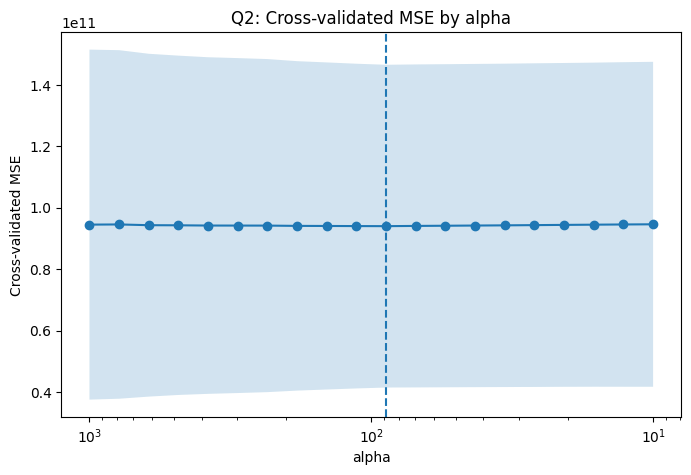

In [4]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)
std_mse = lasso_cv.mse_path_.std(axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker="o")
plt.fill_between(lasso_cv.alphas_, mean_mse - std_mse, mean_mse + std_mse, alpha=0.2)
plt.axvline(lasso_cv.alpha_, linestyle="--")
plt.gca().invert_xaxis()
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Q2: Cross-validated MSE by alpha")
plt.show()

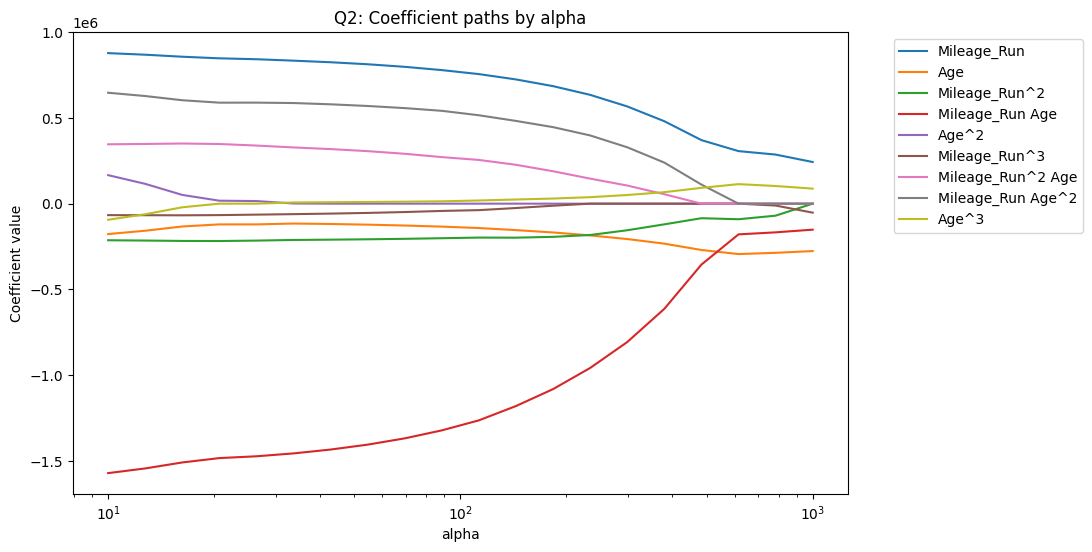

In [5]:
coef_path = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=500000)
    model.fit(X_scaled, y)
    coef_path.append(model.coef_)

coef_path = np.array(coef_path)

plt.figure(figsize=(10,6))
for j, name in enumerate(feature_names):
    plt.semilogx(alphas, coef_path[:, j], label=name)

plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Q2: Coefficient paths by alpha")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

### ANSWERS
3.1 Can be found in code below.
3.2 Yes, some of the signs in the ordinary linear model look somewhat counterintuitive when reading each coefficient by itself. For example, the linear term for age came out positive, but age^2 came out negative and age^3 came out positive. In addition, serum_creatinine was negative in the plain linear fit even though higher-order terms involving it changed the overall pattern. These things can happen when predictors are related to each other, and when the model includes polynomial and interaction terms. Once those higher-order terms are in the model, a single coefficient does not tell the full story anymore. The combined effect can still make sense even if one isolated sign looks weird at first.
3.3 Can be found in code below (alpha = np.logspace(-5,5,30)).
3.4 Can be found in code below.
3.5 Can be found in code below.
3.6 The features selected by LASSO were: ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']. This means LASSO kept 12 out of 33 features, and the proportion set equal to zero was 0.636.

The coefficients that increased in magnitude from linear regression to LASSO were: ['serum_creatinine^3'].

The coefficients that changed sign were: ['age', 'serum_creatinine', 'age^2', 'age ejection_fraction', 'age serum_creatinine', 'ejection_fraction^2', 'ejection_fraction serum_creatinine', 'serum_creatinine^2', 'age^2 ejection_fraction', 'age^2 serum_creatinine', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age serum_creatinine^2', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'ejection_fraction serum_creatinine^2', 'anaemia', 'diabetes', 'high_blood_pressure', 'smoking', 'anaemia diabetes', 'anaemia high_blood_pressure', 'anaemia smoking', 'anaemia diabetes high_blood_pressure', 'anaemia diabetes smoking', 'anaemia high_blood_pressure smoking', 'diabetes high_blood_pressure smoking']. 

It seems that the LASSO sign pattern makes more sense due to it being less noisy. The ordinary linear model seems to estimate many terms at once, making it easier for variance to increase and coefficients that are hard to interpret. On the other hand, LASSO shrinks many of these unstable terms and removes many of them in the process. Overall, from a bias-variance trade-off perspective, it adds some bias but returns a lower variance and a more stable and cleaner model.

In [6]:
heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

y = heart['DEATH_EVENT']

cont_vars = ['age', 'ejection_fraction', 'serum_creatinine']
dummy_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(heart[cont_vars])
cont_feature_names = poly_cont.get_feature_names_out(cont_vars)

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

poly_dummy = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
X_dummy_inter = poly_dummy.fit_transform(heart[dummy_vars])
dummy_feature_names = poly_dummy.get_feature_names_out(dummy_vars)

X_all = np.concatenate([X_cont_scaled, X_dummy_inter], axis=1)
feature_names_all = np.concatenate([cont_feature_names, dummy_feature_names])

linreg_q3 = LinearRegression()
linreg_q3.fit(X_all, y)

coef_df_lin_q3 = pd.DataFrame({
    'feature': feature_names_all,
    'linear_coef': linreg_q3.coef_
})
coef_df_lin_q3

,feature,linear_coef
0,age,1.549928
1,ejection_fraction,-2.025371
2,serum_creatinine,-0.739027
3,age^2,-3.547991
4,age ejection_fraction,-0.861860
5,age serum_creatinine,1.680570
6,ejection_fraction^2,3.317931
7,ejection_fraction serum_creatinine,2.604767
8,serum_creatinine^2,-2.703084
9,age^3,1.889040


Best alpha: 0.005736152510448681


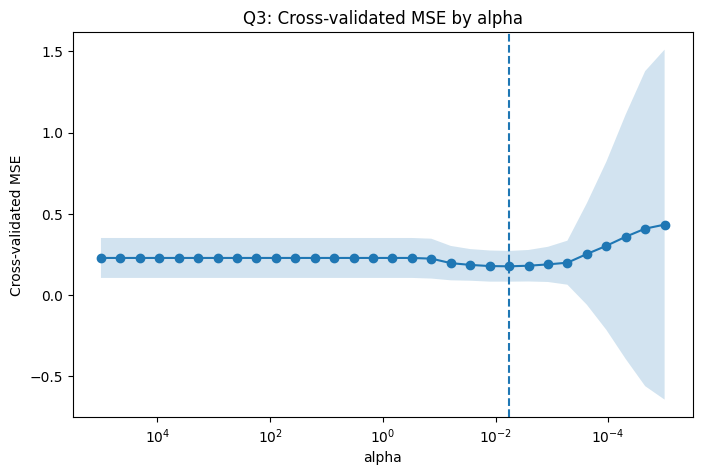

In [7]:
alphas_q3 = np.logspace(-5, 5, 30)

lasso_cv_q3 = LassoCV(alphas=alphas_q3, cv=20, max_iter=300000, random_state=42)
lasso_cv_q3.fit(X_all, y)

print('Best alpha:', lasso_cv_q3.alpha_)

mean_mse_q3 = lasso_cv_q3.mse_path_.mean(axis=1)
std_mse_q3 = lasso_cv_q3.mse_path_.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv_q3.alphas_, mean_mse_q3, marker='o')
plt.fill_between(lasso_cv_q3.alphas_, mean_mse_q3 - std_mse_q3, mean_mse_q3 + std_mse_q3, alpha=0.2)
plt.axvline(lasso_cv_q3.alpha_, linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Q3: Cross-validated MSE by alpha')
plt.gca().invert_xaxis()
plt.show()

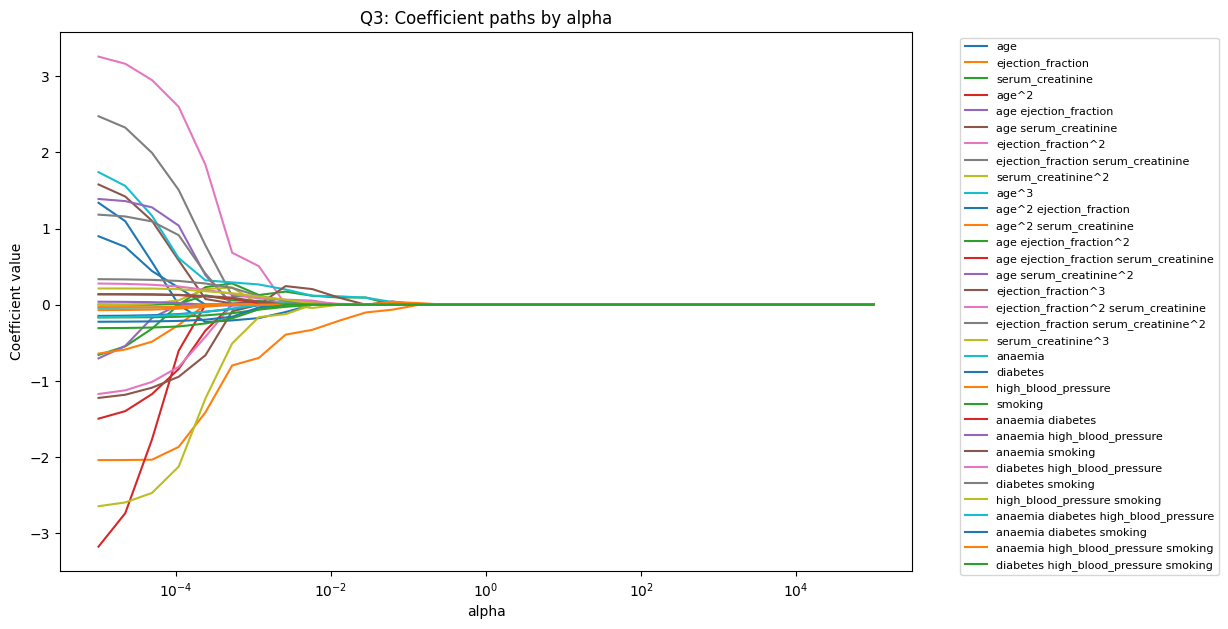

In [8]:
coef_path_q3 = []

for a in alphas_q3:
    model = LassoCV(alphas=[a], cv=20, max_iter=300000, random_state=42)
    model.fit(X_all, y)
    coef_path_q3.append(model.coef_)

coef_path_q3 = np.array(coef_path_q3)

plt.figure(figsize=(11, 7))
for j, name in enumerate(feature_names_all):
    plt.semilogx(alphas_q3, coef_path_q3[:, j], label=name)

plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('Q3: Coefficient paths by alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [9]:
coef_compare_q3 = pd.DataFrame({
    'feature': feature_names_all,
    'linear_coef': linreg_q3.coef_,
    'lasso_coef': lasso_cv_q3.coef_
})

coef_compare_q3['selected_by_lasso'] = coef_compare_q3['lasso_coef'] != 0
coef_compare_q3['abs_linear'] = np.abs(coef_compare_q3['linear_coef'])
coef_compare_q3['abs_lasso'] = np.abs(coef_compare_q3['lasso_coef'])
coef_compare_q3['increased_magnitude'] = coef_compare_q3['abs_lasso'] > coef_compare_q3['abs_linear']
coef_compare_q3['sign_changed'] = np.sign(coef_compare_q3['linear_coef']) != np.sign(coef_compare_q3['lasso_coef'])

coef_compare_q3

,feature,linear_coef,lasso_coef,selected_by_lasso,abs_linear,abs_lasso,increased_magnitude,sign_changed
0,age,1.549928,-0.000000,False,1.549928,0.000000,False,True
1,ejection_fraction,-2.025371,-0.329656,True,2.025371,0.329656,False,False
2,serum_creatinine,-0.739027,0.116875,True,0.739027,0.116875,False,True
3,age^2,-3.547991,0.000000,False,3.547991,0.000000,False,True
4,age ejection_fraction,-0.861860,-0.000000,False,0.861860,0.000000,False,True
5,age serum_creatinine,1.680570,0.000000,False,1.680570,0.000000,False,True
6,ejection_fraction^2,3.317931,0.000000,False,3.317931,0.000000,False,True
7,ejection_fraction serum_creatinine,2.604767,0.000000,False,2.604767,0.000000,False,True
8,serum_creatinine^2,-2.703084,-0.000000,False,2.703084,0.000000,False,True
9,age^3,1.889040,0.117992,True,1.889040,0.117992,False,False


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

### ANSWERS
4.1 The ridge objective function is:

$$
J(b_0,b_1)
=
\frac{1}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha b_1^2.
$$

4.2 First, take the derivative with respect to $b_0$:

$$
\frac{\partial J}{\partial b_0}
=
-\frac{2}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1\tilde{x}_i).
$$

Set this equal to 0:

$$
-\frac{2}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1\tilde{x}_i)=0.
$$

This gives

$$
\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1\tilde{x}_i)=0.
$$

Expanding,

$$
\sum_{i=1}^n \tilde{y}_i - nb_0 - b_1\sum_{i=1}^n \tilde{x}_i = 0.
$$

Since the variables are centered,

$$
\sum_{i=1}^n \tilde{y}_i = 0
\quad \text{and} \quad
\sum_{i=1}^n \tilde{x}_i = 0.
$$

So this becomes

$$
0 - nb_0 - b_1(0) = 0,
$$

which implies

$$
b_0 = 0.
$$

Now take the derivative with respect to $b_1$:

$$
\frac{\partial J}{\partial b_1}
=
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_0 - b_1\tilde{x}_i) + 2\alpha b_1.
$$

Since $b_0 = 0$, this becomes

$$
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + 2\alpha b_1 = 0.
$$

Expanding the summation,

$$
-\frac{2}{n}\sum_{i=1}^n \tilde{x}_i\tilde{y}_i
+
\frac{2}{n}b_1\sum_{i=1}^n \tilde{x}_i^2
+
2\alpha b_1
=
0.
$$

Move the first term to the other side:

$$
\frac{2}{n}b_1\sum_{i=1}^n \tilde{x}_i^2 + 2\alpha b_1
=
\frac{2}{n}\sum_{i=1}^n \tilde{x}_i\tilde{y}_i.
$$

Factor out $b_1$:

$$
b_1\left(\frac{2}{n}\sum_{i=1}^n \tilde{x}_i^2 + 2\alpha\right)
=
\frac{2}{n}\sum_{i=1}^n \tilde{x}_i\tilde{y}_i.
$$

Divide both sides by 2:

$$
b_1\left(\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha\right)
=
\frac{1}{n}\sum_{i=1}^n \tilde{x}_i\tilde{y}_i.
$$

So,

$$
b_1
=
\frac{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i\tilde{y}_i}
{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha}.
$$

Multiplying numerator and denominator by $n$ gives

$$
b_1
=
\frac{\sum_{i=1}^n \tilde{x}_i\tilde{y}_i}
{\sum_{i=1}^n \tilde{x}_i^2 + n\alpha}.
$$

So the final answers are

$$
b_0 = 0
\quad \text{and} \quad
b_1
=
\frac{\sum_{i=1}^n \tilde{x}_i\tilde{y}_i}
{\sum_{i=1}^n \tilde{x}_i^2 + n\alpha}.
$$

4.3 As $\alpha$ gets bigger, the denominator

$$
\sum_{i=1}^n \tilde{x}_i^2 + n\alpha
$$

gets bigger too. That means $b_1$ gets smaller in magnitude, so the slope is pulled closer to 0. In other words, increasing the ridge penalty shrinks the slope more.

4.4 With the LASSO penalty, the objective function becomes

$$
J(b_0,b_1)
=
\frac{1}{n}\sum_{i=1}^n (\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha |b_1|.
$$

The main issue is that $|b_1|$ is not differentiable at $b_1 = 0$, so we cannot use one single derivative the same way we did for ridge.

Instead, we consider cases. If $b_1 > 0$, then $|b_1| = b_1$, and if $b_1 < 0$, then $|b_1| = -b_1$. At $b_1 = 0$, there is no ordinary derivative. This is the reason LASSO can set coefficients exactly equal to 0.

It is optimal to set $b_1 = 0$ when the relationship between $\tilde{x}$ and $\tilde{y}$ is not strong enough to overcome the penalty. The condition is

$$
\left|\frac{1}{n}\sum_{i=1}^n \tilde{x}_i\tilde{y}_i\right|
\le
\frac{\alpha}{2}.
$$

Equivalently,

$$
\left|\sum_{i=1}^n \tilde{x}_i\tilde{y}_i\right|
\le
\frac{n\alpha}{2}.
$$

So unlike ridge, which usually only shrinks the slope toward 0, LASSO can make the slope exactly equal to 0.